In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# SWING

In [2]:
header_list = ["Cause Gene", "Effect Gene", "mean_importance"]
gold_standard = {}
Nodes = [10, 20, 50, 100]
step = 10

mean_important_array_SWING = {}
mean_important_array_rand_SWING = {}
mean_important_array_crand_SWING = {}

mean_important_array_dynGENIE3 = {}
mean_important_array_rand_dynGENIE3 = {}
mean_important_array_crand_dynGENIE3 = {}

for nodes in Nodes:
    
    mean_important_array_SWING[f"mean_important_array_SWING_{nodes}"] = np.array([])
    mean_important_array_rand_SWING[f"mean_important_array_rand_SWING_{nodes}"] = np.array([])
    mean_important_array_crand_SWING[f"mean_important_array_crand_SWING_{nodes}"] = np.array([])
    
    mean_important_array_dynGENIE3[f"mean_important_array_dynGENIE3_{nodes}"] = np.array([])
    mean_important_array_rand_dynGENIE3[f"mean_important_array_rand_dynGENIE3_{nodes}"] = np.array([])
    mean_important_array_crand_dynGENIE3[f"mean_important_array_crand_dynGENIE3_{nodes}"] = np.array([])
   
    for instance in range(100):
        
        instance = instance + 1
        
        mean_importance_file_SWING = pd.read_csv(f"networks_in_out_degree_2_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_SWING_{instance}.tsv", sep ="\t")
        mean_importance_file_SWING_rand = pd.read_csv(f"networks_in_out_degree_2_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_SWING_{instance}_rand.tsv", sep ="\t")
        mean_importance_file_SWING_crand = pd.read_csv(f"networks_in_out_degree_2_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_crand/mean_importance_SWING_{instance}_crand.tsv", sep ="\t")
        
        mean_importance_file_dynGENIE3 = pd.read_csv(f"networks_in_out_degree_2_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_dynGENIE3_{instance}", sep ="\t")
        mean_importance_file_dynGENIE3_rand = pd.read_csv(f"networks_in_out_degree_2_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_dynGENIE3_{instance}_rand.tsv", sep ="\t", names = header_list)
        mean_importance_file_dynGENIE3_crand = pd.read_csv(f"networks_in_out_degree_2_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_crand/mean_importance_dynGENIE3_{instance}_crand.tsv", sep ="\t", names = header_list)
    
        mean_important_array_SWING[f"mean_important_array_SWING_{nodes}"] = np.append(mean_important_array_SWING[f"mean_important_array_SWING_{nodes}"], mean_importance_file_SWING[f"mean_importance"].values)
        mean_important_array_rand_SWING[f"mean_important_array_rand_SWING_{nodes}"] = np.append(mean_important_array_rand_SWING[f"mean_important_array_rand_SWING_{nodes}"], mean_importance_file_SWING_rand[f"mean_importance"].values)
        mean_important_array_crand_SWING[f"mean_important_array_crand_SWING_{nodes}"] = np.append(mean_important_array_crand_SWING[f"mean_important_array_crand_SWING_{nodes}"], mean_importance_file_SWING_crand[f"mean_importance"].values)
        
        mean_important_array_dynGENIE3[f"mean_important_array_dynGENIE3_{nodes}"] = np.append(mean_important_array_dynGENIE3[f"mean_important_array_dynGENIE3_{nodes}"], mean_importance_file_dynGENIE3[f"mean_importance"].values)
        mean_important_array_rand_dynGENIE3[f"mean_important_array_rand_dynGENIE3_{nodes}"] = np.append(mean_important_array_rand_dynGENIE3[f"mean_important_array_rand_dynGENIE3_{nodes}"], mean_importance_file_dynGENIE3_rand[f"mean_importance"].values)
        mean_important_array_crand_dynGENIE3[f"mean_important_array_crand_dynGENIE3_{nodes}"] = np.append(mean_important_array_crand_dynGENIE3[f"mean_important_array_crand_dynGENIE3_{nodes}"], mean_importance_file_dynGENIE3_crand[f"mean_importance"].values)
        
        

# Histogram 10 genes

## SWING

mean:  0.024815244056159428
mean rand:  0.030286811282010086
estandard desv:  0.02294791300457248
estandard desv rand:  0.012426485219165943
most frequent value:  0.2220221751942827   44.540668005087625
most frequent value rand:  0.1100793570231121   45.428436779082254


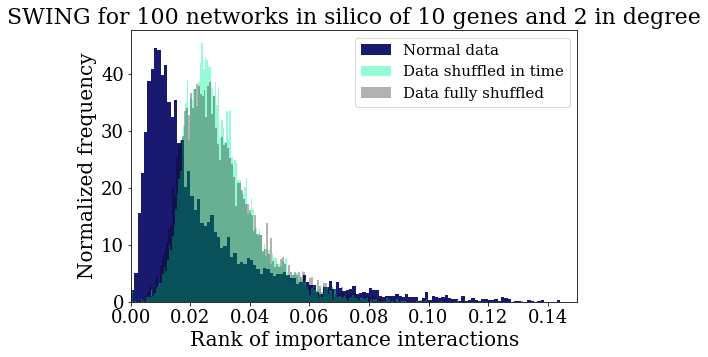

In [54]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

y, x, _ = plt.hist(mean_important_array_SWING["mean_important_array_SWING_10"], bins = 200, color = "midnightblue", density =1, label = r"Normal data")
y_rand, x_rand, _ = plt.hist(mean_important_array_rand_SWING["mean_important_array_rand_SWING_10"], bins = 200, color='mediumspringgreen', alpha = 0.41, density = 1, label = r"Data shuffled in time")
y_crand, x_crand, _ = plt.hist(mean_important_array_crand_SWING["mean_important_array_crand_SWING_10"], bins = 200, color='k', alpha = 0.3, density = 1, label = r"Data fully shuffled")

plt.ylabel("Normalized frequency", fontsize = 20)
plt.xlabel("Rank of importance interactions", fontsize = 20)
plt.title("SWING for 100 networks in silico of 10 genes and 2 in degree", fontsize = 22)
plt.xlim(0,0.15)
plt.legend(prop={"size":15, "family":"serif"})

#Statistics
print("mean: ", mean_important_array_SWING["mean_important_array_SWING_10"].mean())
print("mean rand: ", mean_important_array_rand_SWING["mean_important_array_rand_SWING_10"].mean())
print("estandard desv: ", mean_important_array_SWING["mean_important_array_SWING_10"].std())
print("estandard desv rand: ", mean_important_array_rand_SWING["mean_important_array_rand_SWING_10"].std())

print("most frequent value: ", x.max(), " ", y.max())
print("most frequent value rand: ",  x_rand.max(), " ", y_rand.max())

## dynGENIE3

mean:  0.11099999666666667
mean rand:  0.11099999688888888
estandard desv:  0.073630544228577
estandard desv rand:  0.04858651473159321
most frequent value:  0.543512   9.322087951446616
most frequent value rand:  0.520043   14.357787080427308


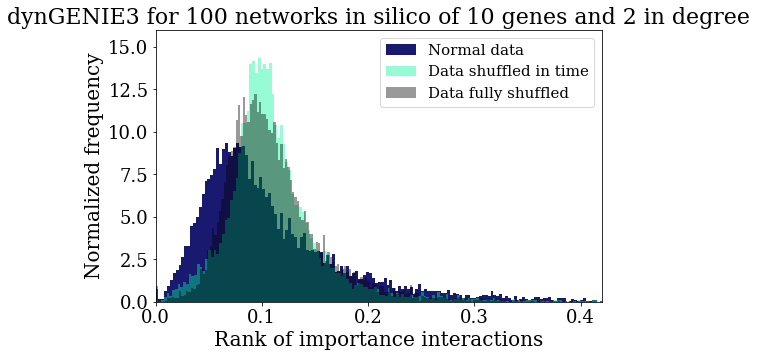

In [55]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

y, x, _ = plt.hist(mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_10"], bins = 200, color = "midnightblue", density =1, label = r"Normal data")
y_rand, x_rand, _ = plt.hist(mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_10"], bins = 200,color='mediumspringgreen', alpha = 0.41, density = 1, label = r"Data shuffled in time")
y_crand, x_crand, _ = plt.hist(mean_important_array_crand_dynGENIE3["mean_important_array_crand_dynGENIE3_10"], bins = 200,color='k', alpha = 0.4, density = 1, label = r"Data fully shuffled")

plt.ylabel("Normalized frequency", fontsize = 20, family = "serif")
plt.xlabel("Rank of importance interactions", fontsize = 20)
plt.title("dynGENIE3 for 100 networks in silico of 10 genes and 2 in degree", fontsize = 22)
plt.xlim(0,0.42)
plt.ylim(0,16)
plt.legend(prop={"size":15, "family":"serif"})

#Statistics
print("mean: ", mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_10"].mean())
print("mean rand: ", mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_10"].mean())
print("estandard desv: ", mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_10"].std())
print("estandard desv rand: ", mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_10"].std())

print("most frequent value: ", x.max(), " ", y.max())
print("most frequent value rand: ",  x_rand.max(), " ", y_rand.max())

# Histogram 20 genes

## SWING

mean:  0.013234878669132338
mean rand:  0.015476331307552169
estandard desv:  0.014764021396231265
estandard desv rand:  0.008124291569299792
most frequent value:  0.1181802731036947   99.17949615530824
most frequent value rand:  0.0934419891288803   84.20898803020778


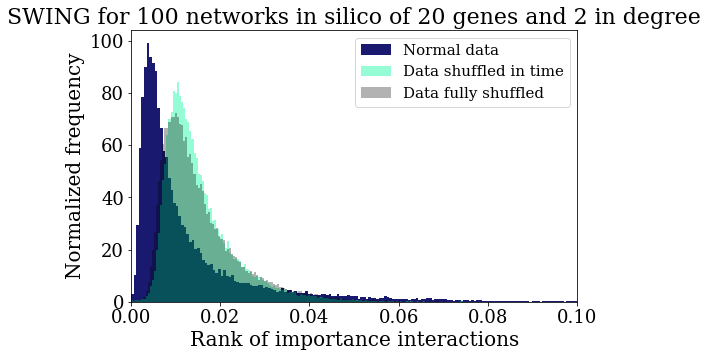

In [56]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

y, x, _ = plt.hist(mean_important_array_SWING["mean_important_array_SWING_20"], bins = 200, color = "midnightblue", density =1, label = r"Normal data")
y_rand, x_rand, _ = plt.hist(mean_important_array_rand_SWING["mean_important_array_rand_SWING_20"], bins = 200, color='mediumspringgreen', alpha = 0.41, density = 1, label = r"Data shuffled in time")
y_crand, x_crand, _ = plt.hist(mean_important_array_crand_SWING["mean_important_array_crand_SWING_20"], bins = 200, color='k', alpha = 0.3, density = 1, label = r"Data fully shuffled")

plt.ylabel("Normalized frequency", fontsize = 20)
plt.xlabel("Rank of importance interactions", fontsize = 20)
plt.title("SWING for 100 networks in silico of 20 genes and 2 in degree", fontsize = 22)
plt.xlim(0,0.1)
plt.legend(prop={"size":15, "family":"serif"})

#Statistics
print("mean: ", mean_important_array_SWING["mean_important_array_SWING_20"].mean())
print("mean rand: ", mean_important_array_rand_SWING["mean_important_array_rand_SWING_20"].mean())
print("estandard desv: ", mean_important_array_SWING["mean_important_array_SWING_20"].std())
print("estandard desv rand: ", mean_important_array_rand_SWING["mean_important_array_rand_SWING_20"].std())

print("most frequent value: ", x.max(), " ", y.max())
print("most frequent value rand: ",  x_rand.max(), " ", y_rand.max())

## dynGENIE3

mean:  0.05260526618421052
mean rand:  0.05263157955263158
estandard desv:  0.04086325287924622
estandard desv rand:  0.02722785594513047
most frequent value:  0.398299   20.91790074132354
most frequent value rand:  0.372425   26.34264087801268


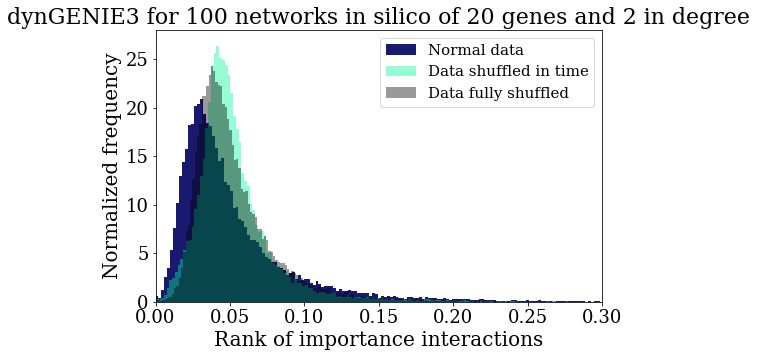

In [57]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

y, x, _ = plt.hist(mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_20"], bins = 200, color = "midnightblue", density =1, label = r"Normal data")
y_rand, x_rand, _ = plt.hist(mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_20"], bins = 200,color='mediumspringgreen', alpha = 0.41, density = 1, label = r"Data shuffled in time")
y_crand, x_crand, _ = plt.hist(mean_important_array_crand_dynGENIE3["mean_important_array_crand_dynGENIE3_20"], bins = 200,color='k', alpha = 0.4, density = 1, label = r"Data fully shuffled")

plt.ylabel("Normalized frequency", fontsize = 20, family = "serif")
plt.xlabel("Rank of importance interactions", fontsize = 20)
plt.title("dynGENIE3 for 100 networks in silico of 20 genes and 2 in degree", fontsize = 22)
plt.xlim(0,0.3)
plt.ylim(0,28)
plt.legend(prop={"size":15, "family":"serif"})

#Statistics
print("mean: ", mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_20"].mean())
print("mean rand: ", mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_20"].mean())
print("estandard desv: ", mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_20"].std())
print("estandard desv rand: ", mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_20"].std())

print("most frequent value: ", x.max(), " ", y.max())
print("most frequent value rand: ",  x_rand.max(), " ", y_rand.max())

# Histogram 50 genes

## SWING

mean:  0.005662593287077672
mean rand:  0.006377020166345743
estandard desv:  0.00800741291798336
estandard desv rand:  0.004183018154665537
most frequent value:  0.0909610831192355   267.5133715151914
most frequent value rand:  0.0644040512182548   193.10749677701426


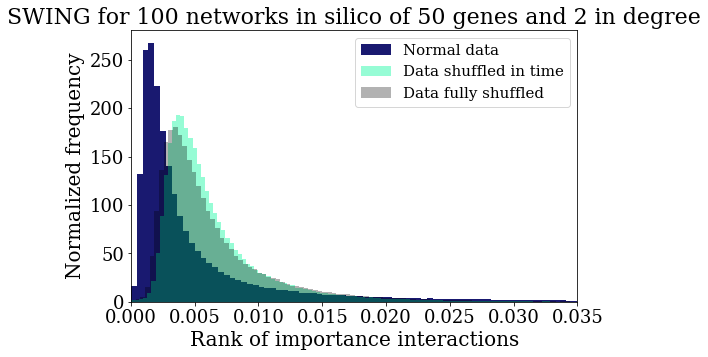

In [58]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

y, x, _ = plt.hist(mean_important_array_SWING["mean_important_array_SWING_50"], bins = 200, color = "midnightblue", density =1, label = r"Normal data")
y_rand, x_rand, _ = plt.hist(mean_important_array_rand_SWING["mean_important_array_rand_SWING_50"], bins = 200, color='mediumspringgreen', alpha = 0.41, density = 1, label = r"Data shuffled in time")
y_crand, x_crand, _ = plt.hist(mean_important_array_crand_SWING["mean_important_array_crand_SWING_50"], bins = 200, color='k', alpha = 0.3, density = 1, label = r"Data fully shuffled")

plt.ylabel("Normalized frequency", fontsize = 20)
plt.xlabel("Rank of importance interactions", fontsize = 20)
plt.title("SWING for 100 networks in silico of 50 genes and 2 in degree", fontsize = 22)
plt.xlim(0,0.035)
plt.legend(prop={"size":15, "family":"serif"})

#Statistics
print("mean: ", mean_important_array_SWING["mean_important_array_SWING_50"].mean())
print("mean rand: ", mean_important_array_rand_SWING["mean_important_array_rand_SWING_50"].mean())
print("estandard desv: ", mean_important_array_SWING["mean_important_array_SWING_50"].std())
print("estandard desv rand: ", mean_important_array_rand_SWING["mean_important_array_rand_SWING_50"].std())

print("most frequent value: ", x.max(), " ", y.max())
print("most frequent value rand: ",  x_rand.max(), " ", y_rand.max())

## dynGENIE3

mean:  0.020404082281632655
mean rand:  0.020404081783673464
estandard desv:  0.02071101952707088
estandard desv rand:  0.01412933850060587
most frequent value:  0.304936   58.29259321326976
most frequent value rand:  0.25217   60.94042486725423


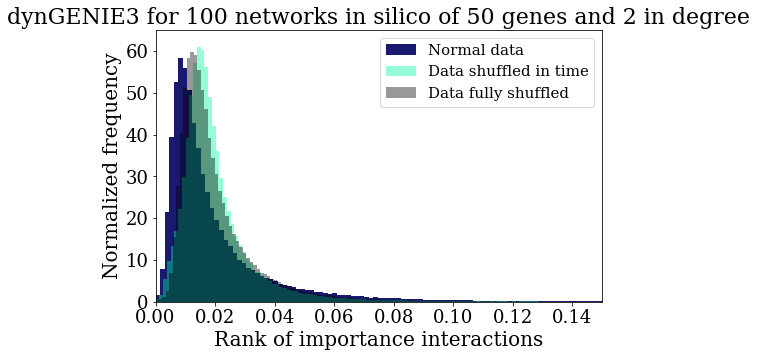

In [59]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rcParams["font.family"] = "serif"

y, x, _ = plt.hist(mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_50"], bins = 200, color = "midnightblue", density =1, label = r"Normal data")
y_rand, x_rand, _ = plt.hist(mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_50"], bins = 200,color='mediumspringgreen', alpha = 0.41, density = 1, label = r"Data shuffled in time")
y_crand, x_crand, _ = plt.hist(mean_important_array_crand_dynGENIE3["mean_important_array_crand_dynGENIE3_50"], bins = 200,color='k', alpha = 0.4, density = 1, label = r"Data fully shuffled")

plt.ylabel("Normalized frequency", fontsize = 20, family = "serif")
plt.xlabel("Rank of importance interactions", fontsize = 20)
plt.title("dynGENIE3 for 100 networks in silico of 50 genes and 2 in degree", fontsize = 22)
plt.xlim(0,0.15)
plt.ylim(0,65)
plt.legend(prop={"size":15, "family":"serif"})

#Statistics
print("mean: ", mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_50"].mean())
print("mean rand: ", mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_50"].mean())
print("estandard desv: ", mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_50"].std())
print("estandard desv rand: ", mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_50"].std())

print("most frequent value: ", x.max(), " ", y.max())
print("most frequent value rand: ",  x_rand.max(), " ", y_rand.max())

# Histogram 100 genes

In [4]:
file_path_data = "C:/Users/ivana/OneDrive/Desktop/Imagenes Internship"

## SWING

mean:  0.0029738917244414957
mean rand:  0.003236371096641957
estandard desv:  0.004729869760996659
estandard desv rand:  0.002474963403947177
most frequent value:  0.0661667181574202   520.7873208522365
most frequent value rand:  0.0524847472609692   381.1400730306385


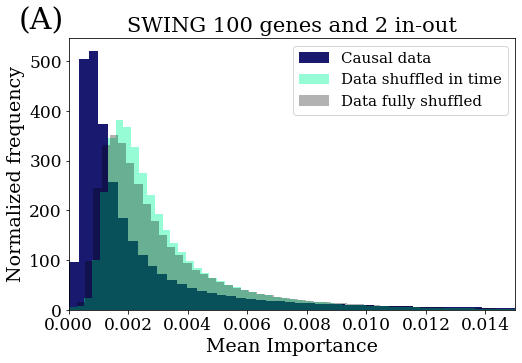

In [5]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=17)
plt.rc('ytick', labelsize=17)
plt.rcParams["font.family"] = "serif"

y, x, _ = plt.hist(mean_important_array_SWING["mean_important_array_SWING_100"], bins = 200, color = "midnightblue", density =1, label = r"Causal data")
y_rand, x_rand, _ = plt.hist(mean_important_array_rand_SWING["mean_important_array_rand_SWING_100"], bins = 200, color='mediumspringgreen', alpha = 0.41, density = 1, label = r"Data shuffled in time")
y_crand, x_crand, _ = plt.hist(mean_important_array_crand_SWING["mean_important_array_crand_SWING_100"], bins = 200, color='k', alpha = 0.3, density = 1, label = r"Data fully shuffled")

plt.ylabel("Normalized frequency", fontsize = 19)
plt.xlabel("Mean Importance", fontsize = 19)
plt.title("SWING 100 genes and 2 in-out", fontsize = 21)
plt.xlim(0,0.015)
plt.text(-0.0017,565, "(A)", fontsize = 30)
plt.legend(prop={"size":15, "family":"serif"})
plt.savefig(f"{file_path_data}/histogram_SWING_100genes_2degree.png", bbox_inches="tight", dpi=100 )

#Statistics
print("mean: ", mean_important_array_SWING["mean_important_array_SWING_100"].mean())
print("mean rand: ", mean_important_array_rand_SWING["mean_important_array_rand_SWING_100"].mean())
print("estandard desv: ", mean_important_array_SWING["mean_important_array_SWING_100"].std())
print("estandard desv rand: ", mean_important_array_rand_SWING["mean_important_array_rand_SWING_100"].std())
print("most frequent value: ", x.max(), " ", y.max())
print("most frequent value rand: ",  x_rand.max(), " ", y_rand.max())

## dynGENIE3

mean:  0.010096970134343438
mean rand:  0.010097980066666668
estandard desv:  0.011647657462159327
estandard desv rand:  0.00821612949378127
most frequent value:  0.21255   123.20048283351036
most frequent value rand:  0.17826   118.94780861458744


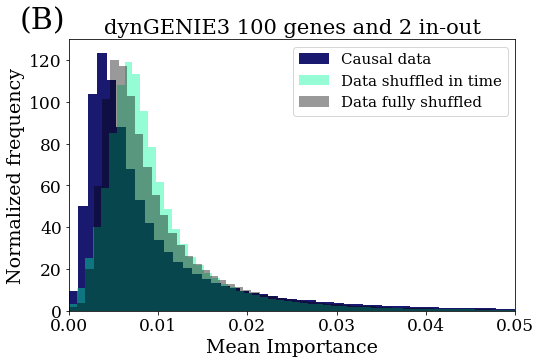

In [6]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=17)
plt.rc('ytick', labelsize=17)
plt.rcParams["font.family"] = "serif"

y, x, _ = plt.hist(mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_100"], bins = 200, color = "midnightblue", density =1, label = r"Causal data")
y_rand, x_rand, _ = plt.hist(mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_100"], bins = 200,color='mediumspringgreen', alpha = 0.41, density = 1, label = r"Data shuffled in time")
y_crand, x_crand, _ = plt.hist(mean_important_array_crand_dynGENIE3["mean_important_array_crand_dynGENIE3_100"], bins = 200,color='k', alpha = 0.4, density = 1, label = r"Data fully shuffled")

plt.ylabel("Normalized frequency", fontsize = 19, family = "serif")
plt.xlabel("Mean Importance", fontsize = 19)
plt.title("dynGENIE3 100 genes and 2 in-out", fontsize = 21)
plt.xlim(0,0.05)
plt.ylim(0,130)
plt.legend(prop={"size":15, "family":"serif"})
plt.text(-0.0055,135, "(B)", fontsize = 30)
plt.savefig(f"{file_path_data}/histogram_dynGENIE3_100genes_2degree.png", bbox_inches="tight", dpi=100 )


#Statistics
print("mean: ", mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_100"].mean())
print("mean rand: ", mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_100"].mean())
print("estandard desv: ", mean_important_array_dynGENIE3["mean_important_array_dynGENIE3_100"].std())
print("estandard desv rand: ", mean_important_array_rand_dynGENIE3["mean_important_array_rand_dynGENIE3_100"].std())

print("most frequent value: ", x.max(), " ", y.max())
print("most frequent value rand: ",  x_rand.max(), " ", y_rand.max())